In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

from pathlib import Path

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.dataset.transforms import GroupMultiScaleCrop, Stack

In [2]:
import math
import numbers
import warnings
import random

import numpy as np
import torch
import torchvision
import torchvision.transforms.functional as F
from PIL import Image, ImageOps

In [3]:
output_dirpath=Path('D:/results/ucf101/video_mae')
output_dirpath.mkdir(parents=True, exist_ok=True)
video_data=torch.load(output_dirpath/'extracted_video_data_numpy.pt', weights_only=False)
print(f'{type(video_data)=}, {video_data.shape}')
images=[Image.fromarray(video_data[vid,]) for vid in range(16)] # convert each frame to PIL.Image

aug_op=GroupMultiScaleCrop(input_size=224, scales=[1, .875, .75, .66])
ret_imgs, label=aug_op((images, None))

type(video_data)=<class 'numpy.ndarray'>, (16, 240, 320, 3)


In [6]:
aug_op=Stack(roll=False)
ret_imgs, label=aug_op((ret_imgs, label))

type(img_group)=<class 'list'>, type(img_group[0])=<class 'PIL.Image.Image'>, img_group[0].mode='RGB'


In [19]:
ret_imgs.shape, ret_imgs.dtype

((224, 224, 48), dtype('uint8'))

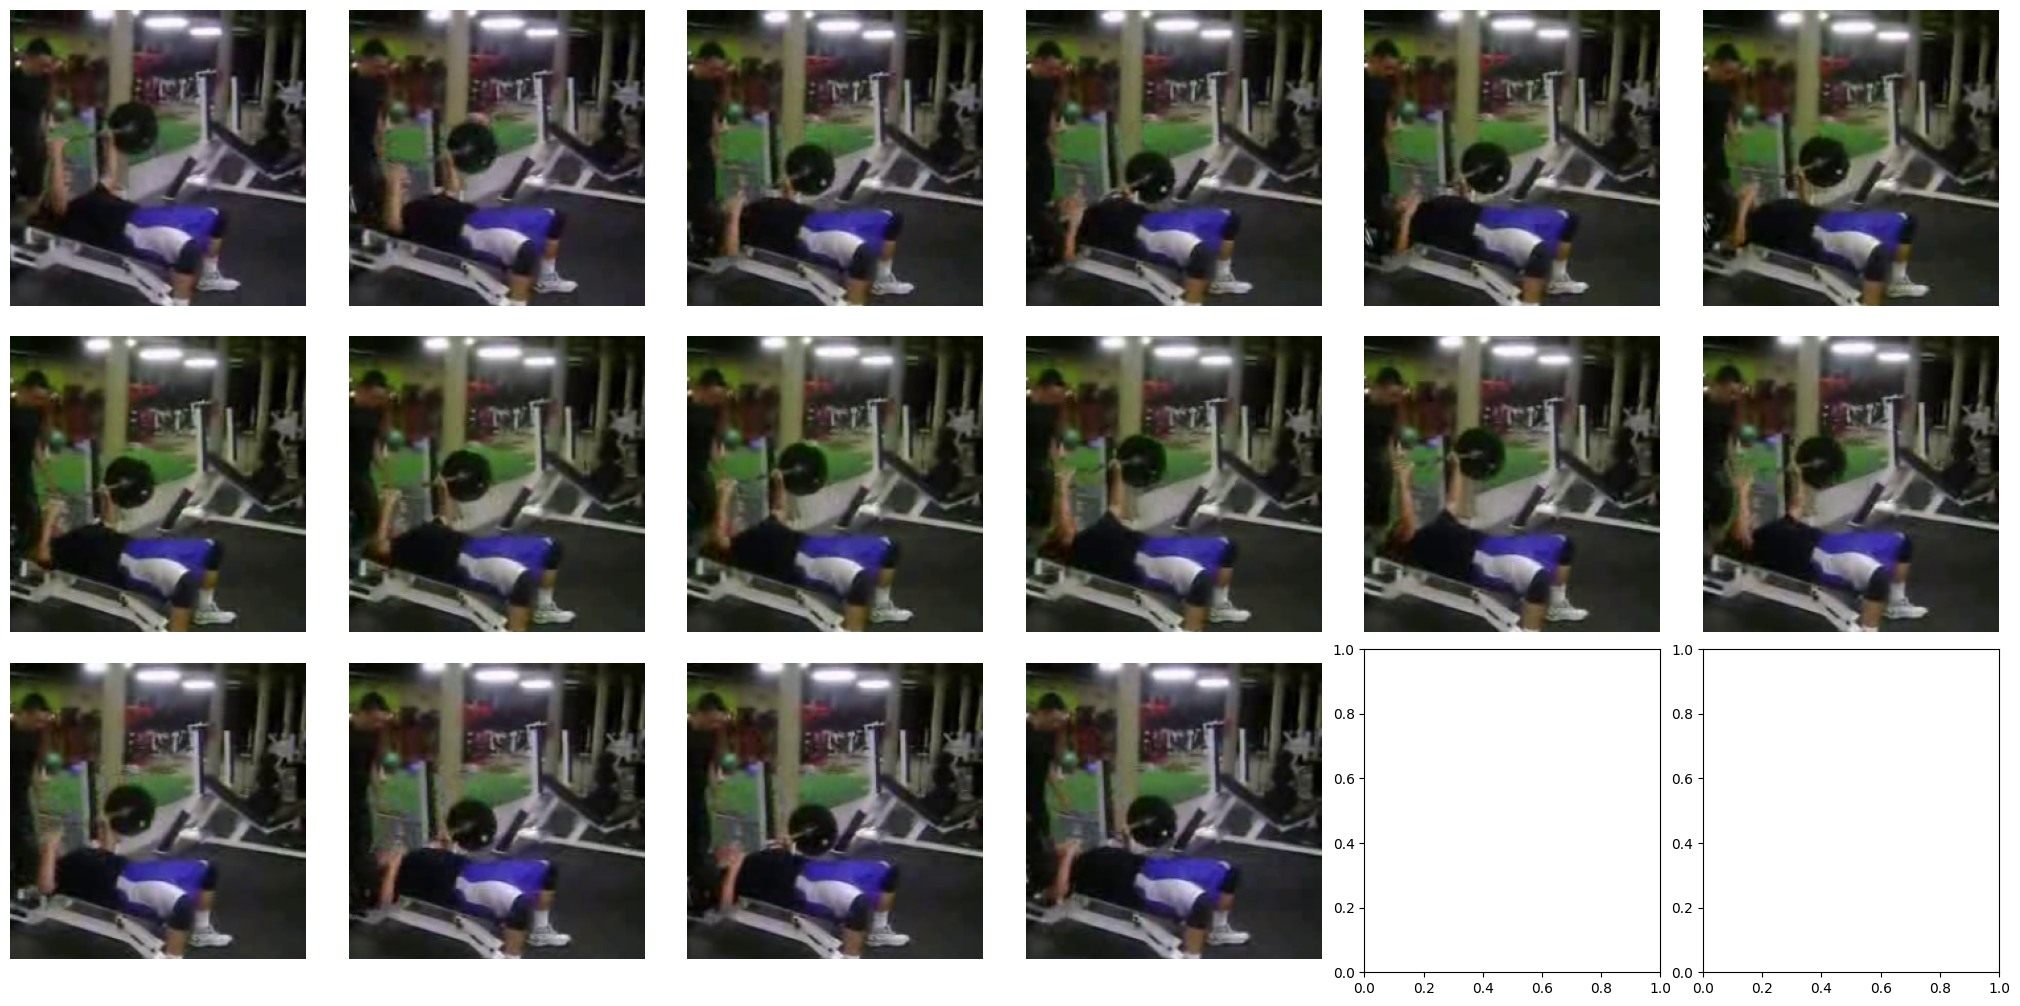

In [18]:
n_frames=ret_imgs.shape[-1]//3
n_cols=6
n_rows=int(np.ceil(n_frames/n_cols))
fig, ax=plt.subplots(n_rows, n_cols, figsize=(20,10))
for i in range(n_rows):
    for j in range(n_cols):
        k=i*n_cols+j
        if k>=n_frames: break
        ax[i,j].imshow(ret_imgs[:,:,3*k:3*(k+1)])
        ax[i,j].axis('off')
plt.tight_layout(pad=0, w_pad=0, h_pad=0)